In [1]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib
matplotlib.use('Agg')
import warnings
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from plotnine import *
import statsmodels.formula.api as smf


#Set random seeds
seed = 210226
warnings.filterwarnings('ignore', category=RuntimeWarning)

sns.set_theme(style="white", font_scale=1.2)

In [53]:
#####-------FILENAMES ETC--------------
dataset_name = "bch" 
raw_file_name = "preprocessed-visits-with-raw-variables"
load_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/"
save_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/"
split_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/prediction/recent-eval/at-triage/"

raw_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/raw-data/"


####--------PREPROCESSING VARIABLES------------

#Define identifier columns.
identifier_cols = ["csn", "is_admitted", "mrn", "minutes_since_first_arrival", "raw_arrival_month", "raw_arrival_year"]

#Define excluded columns-- we do not use these as predictors.
excluded_columns = identifier_cols + ["group", "assigned_order"] #These are excluded from both predictions and IPW calculations.
excluded_prefixes = ['current_diagnosis'] #These are excluded from just predictions.

#Identify gendered predictions; we exclude these when matching patients across sex-based groups
gendered_predictors = ['current_diagnosis_menstrual_disorders', 'pre_diagnosis_menstrual_disorders', 'complaint_contains_abdominal_pain',
                       'complaint_contains_gynecologic', 'complaint_contains_male_genital', 'complaint_contains_pregnancy']

#Separate categorical, pre-binarised, and continuous predictors.
categorical_predictors = [
    'race', 'sex', 'ed_arrival_mode', 'language',
                'insurance', 'home_state', 'year_of_arrival', 'season', 'time_of_day', 'triage_acuity']



#Variables which already 'come pre-binarised'.
pre_binarised_predictors = ['is_trans_or_nb', 'is_weekend',
                            'current_diagnosis_epilepsy', 'current_diagnosis_asthma', 'current_diagnosis_congenital_malformations', 
                'current_diagnosis_depression', 'current_diagnosis_pain_conditions', 'current_diagnosis_anxiety',
                  'current_diagnosis_conduct_disorders', 'current_diagnosis_nausea_and_vomiting',
                    'current_diagnosis_any_malignancy', 'current_diagnosis_gastrointestinal', 
                    'current_diagnosis_developmental_delays', 'current_diagnosis_psychotic_disorders', 
                    'current_diagnosis_cardiovascular', 'current_diagnosis_diabetes_mellitus', 'current_diagnosis_eating_disorders', 
                    'current_diagnosis_weight_loss', 'current_diagnosis_anemia', 'current_diagnosis_chromosomal_anomalies', 
                    'current_diagnosis_drug_abuse', 'current_diagnosis_menstrual_disorders', 'current_diagnosis_sleep_disorders', 
                    'current_diagnosis_smoking', 'current_diagnosis_alcohol_abuse', 'current_diagnosis_joint_disorders', 
                      'pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse', 
                            'complaint_contains_abdominal_pain', 'complaint_contains_assault', 
                            'complaint_contains_allergic_reaction', 'complaint_contains_altered_mental_status',
                              'complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting',
                    ]


#Continuous predictors.
continuous_predictors = [
    'age_in_days', 'miles_travelled', 'sdi_score',
     'crowdedness',  'raw_weight', 
     'num_previous_admissions', 'num_previous_visits_without_admission',
     'raw_triage_dbp', 'raw_triage_hr', 'raw_triage_pain', 'raw_triage_rr', 'raw_triage_sbp', 'raw_triage_sp_o2',
]



#Map races into groups.
race_dict = {
    'Hispanic': 'H',
    'Hispanic White': 'H',
    'Black': 'NHB',
    'Non-Hispanic Black': 'NHB',
    'Asian' : 'Other',
    'Unknown': 'Other',
    'Other': 'Other',
    'White': 'NHW',
    'Non-Hispanic White' : 'NHW'
}




Try to fit a model of individual ED LOS based on their own triage acuity and the triage acuity of those around them. For this, we need a sense of the burden at every arrival point. 

In [57]:
#Load the visits for these projects.
visits = pd.read_csv(save_filepath + 'intermediate-files/visits.csv', index_col=0)


#Classify visits into urgent and non-urgent. (Assume that everyone with no recorded triage acuity is non-urgent).
visits['urgent'] = ((~visits['triage_acuity'].isna()) & ((visits['triage_acuity'] == 1) | (visits['triage_acuity'] == 2))).astype(int)

#Now all we need is the admission status, urgency status, ED LOS and timeline of arrival.
visit_timeline = visits[['csn', 'urgent', 'is_admitted', 'ed_los', 'minutes_since_first_arrival']].copy().sort_values('minutes_since_first_arrival')

#So we need to keep a running count of how many urgent, non-urgent, admitted and non-admitted patients (that's a 4-way contingency table) there are in the ED at any given time.
visit_timeline['visit_type'] = np.char.add(
    np.char.add(
        np.where(visit_timeline['urgent'] == 1, 'urgent', 'non-urgent'),
        '-'
    ),
    np.where(visit_timeline['is_admitted'] == 1, 'admitted', 'discharged')
)

#Denote timestamps.
visit_timeline = visit_timeline.rename(columns={'minutes_since_first_arrival':'arrival'})
visit_timeline['departure'] = visit_timeline['arrival'] + visit_timeline['ed_los']

#Now get a list of events (arrivals/departures)
events = visit_timeline[['visit_type', 'arrival', 'departure']].melt(
    id_vars=['visit_type'],
    value_vars=['arrival', 'departure'],
    var_name='event',
    value_name='timestamp'
).sort_values('timestamp')


#Now expand the dataframe.
visit_types, event_types, timestamps = events['visit_type'].values, np.where(events['event'].values=='arrival', 1, -1), events['timestamp'].values

#Store crowding information in a dictionary. (This will contain information on repeat timestamps; we can deal with that later)
crowding_history, crowding_current = {}, {}
vtypes = events['visit_type'].unique()
for vtype in vtypes:
    crowding_history[vtype] = np.zeros_like(timestamps) #Number of visits of each type at each [UNIQUE] timestamp- about 10% of timestamps have repeat events
    crowding_current[vtype] = 0 #Instantaneous count of visits in the ED, starting at 0

for index, ts in enumerate(timestamps):
    vtype, etype = visit_types[index], event_types[index]
    for vtype_ in vtypes:
        if vtype == vtype_: #If this is the relevant type:
            new_crowding = crowding_current[vtype_] + etype #Update population.
        else:
            new_crowding = crowding_current[vtype_] #Use last known population.
        
        #Now update the current population.
        crowding_history[vtype_][index] = new_crowding
        crowding_current[vtype_] = new_crowding


#Now make a dataframe out of the crowding history.
crowding_history['timestamp'] = timestamps
crowding_history = pd.DataFrame(crowding_history).reset_index()

#Now just keep the last instance of all unique timestamps (we only need to know how things stood at the end of the minute, once all relevant processes have played out).
indices_to_keep = crowding_history[['timestamp', 'index']].groupby('timestamp').agg('max').reset_index()
crowding_history = crowding_history.merge(indices_to_keep[['index']], on='index', how='inner').reset_index(drop=True).drop(columns=['index'])

#Save this.
crowding_history.to_csv(save_filepath+'crowding-history.csv')

#Attach this back to visit timeline.
visit_timeline = visit_timeline.merge(crowding_history, left_on='arrival', right_on='timestamp', how='inner').drop(columns=['timestamp', 'departure'])
visit_timeline.to_csv(save_filepath+'visit-timeline.csv')


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_84117/4290237612.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


Now see if we can fit a distribution to these 'times-to-arrival'. (If not, the crowding history will nonetheless be helpful for predicting individual level ED-LOS with RNNs, for which we'd need admission status and visit diagnoses).

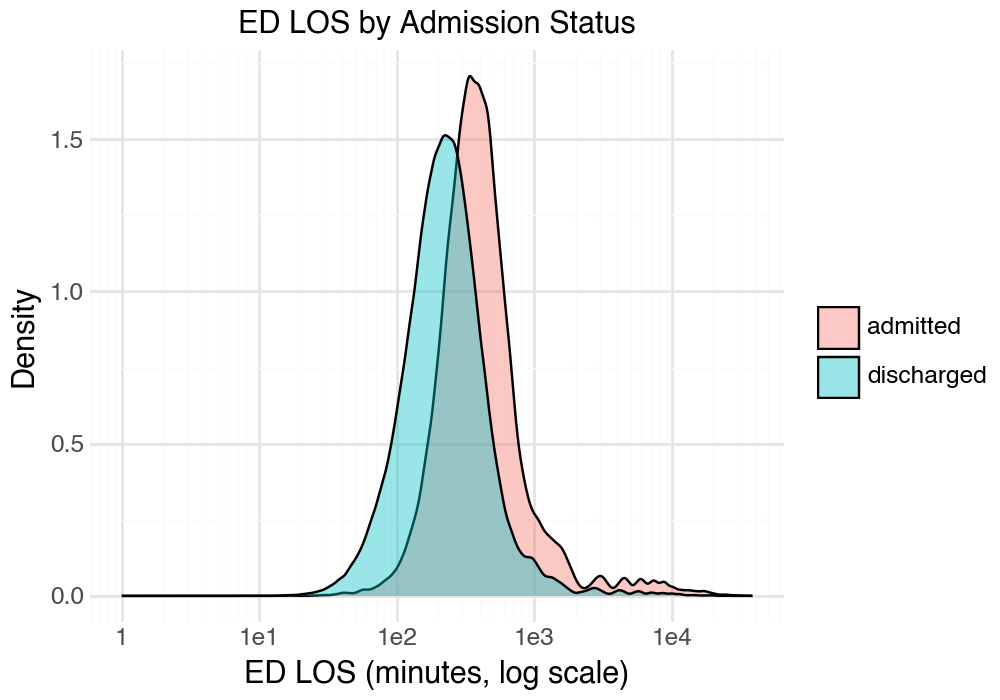

In [58]:
#Load this.
%matplotlib inline
visit_timeline = pd.read_csv(save_filepath+'visit-timeline.csv', index_col=0)

from plotnine import (
    ggplot, aes, geom_density, scale_x_log10,
    labs, theme, theme_minimal, element_text
)

plot_df = visit_timeline.copy()
plot_df['admission_status'] = plot_df['is_admitted'].map({1: 'admitted', 0: 'discharged'})
plot_df['urgency_status'] = plot_df['urgent'].map({1: 'urgent', 0: 'non-urgent'})

def los_density_plot(df, fill_col, title):
    return (
        ggplot(df, aes(x='ed_los', fill=fill_col))
        + geom_density(alpha=0.4)
        + scale_x_log10()
        + labs(title=title, x='ED LOS (minutes, log scale)', y='Density', fill='')
        + theme_minimal()
        + theme(figure_size=(5, 3.5), plot_title=element_text(size=11))
    )

#Plot by admission status.
los_density_plot(plot_df, 'admission_status', 'ED LOS by Admission Status')


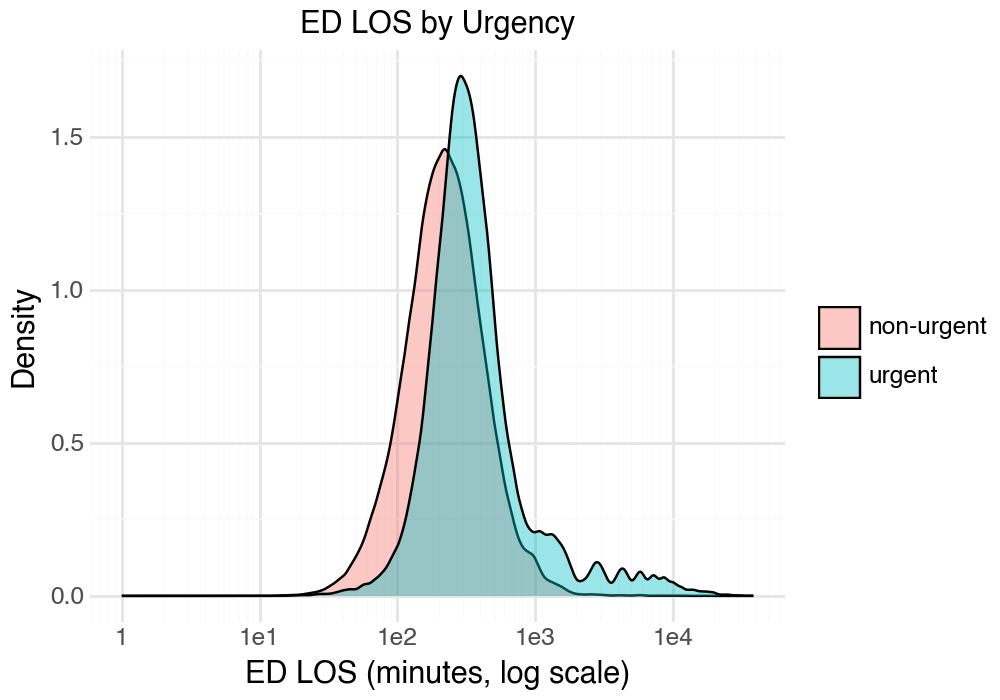

In [59]:
#Plot by urgency.
los_density_plot(plot_df, 'urgency_status', 'ED LOS by Urgency')



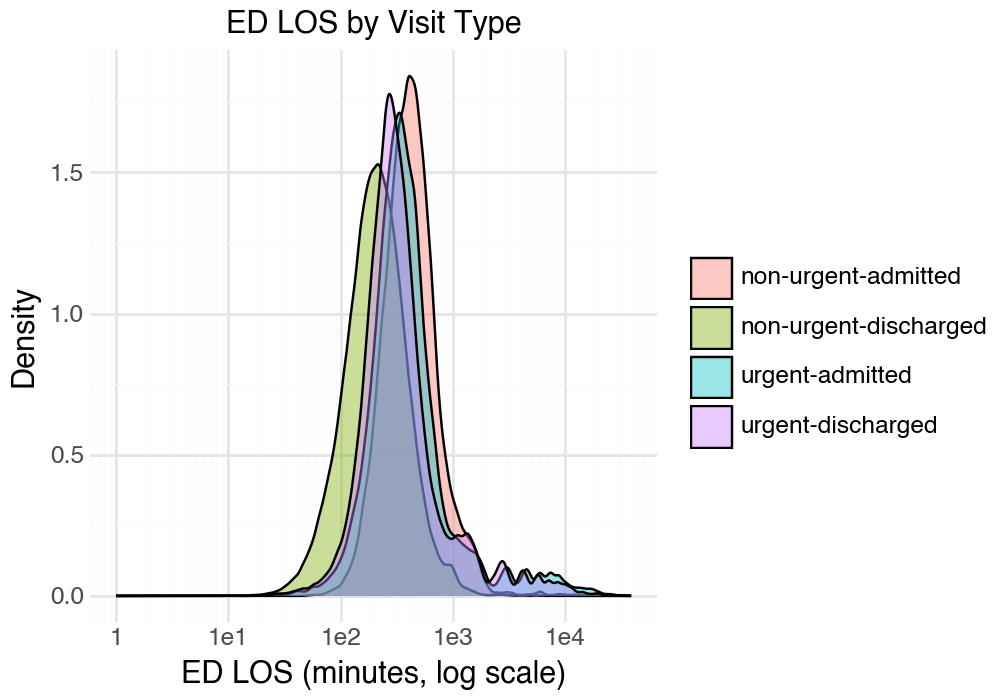

In [60]:
#Plot by visit type.
los_density_plot(plot_df, 'visit_type', 'ED LOS by Visit Type')

Now fit a lognormal distribution to each of these, where a person's wait time depends on their own state and the number of people in every other state.

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_84117/1073469539.py:150: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


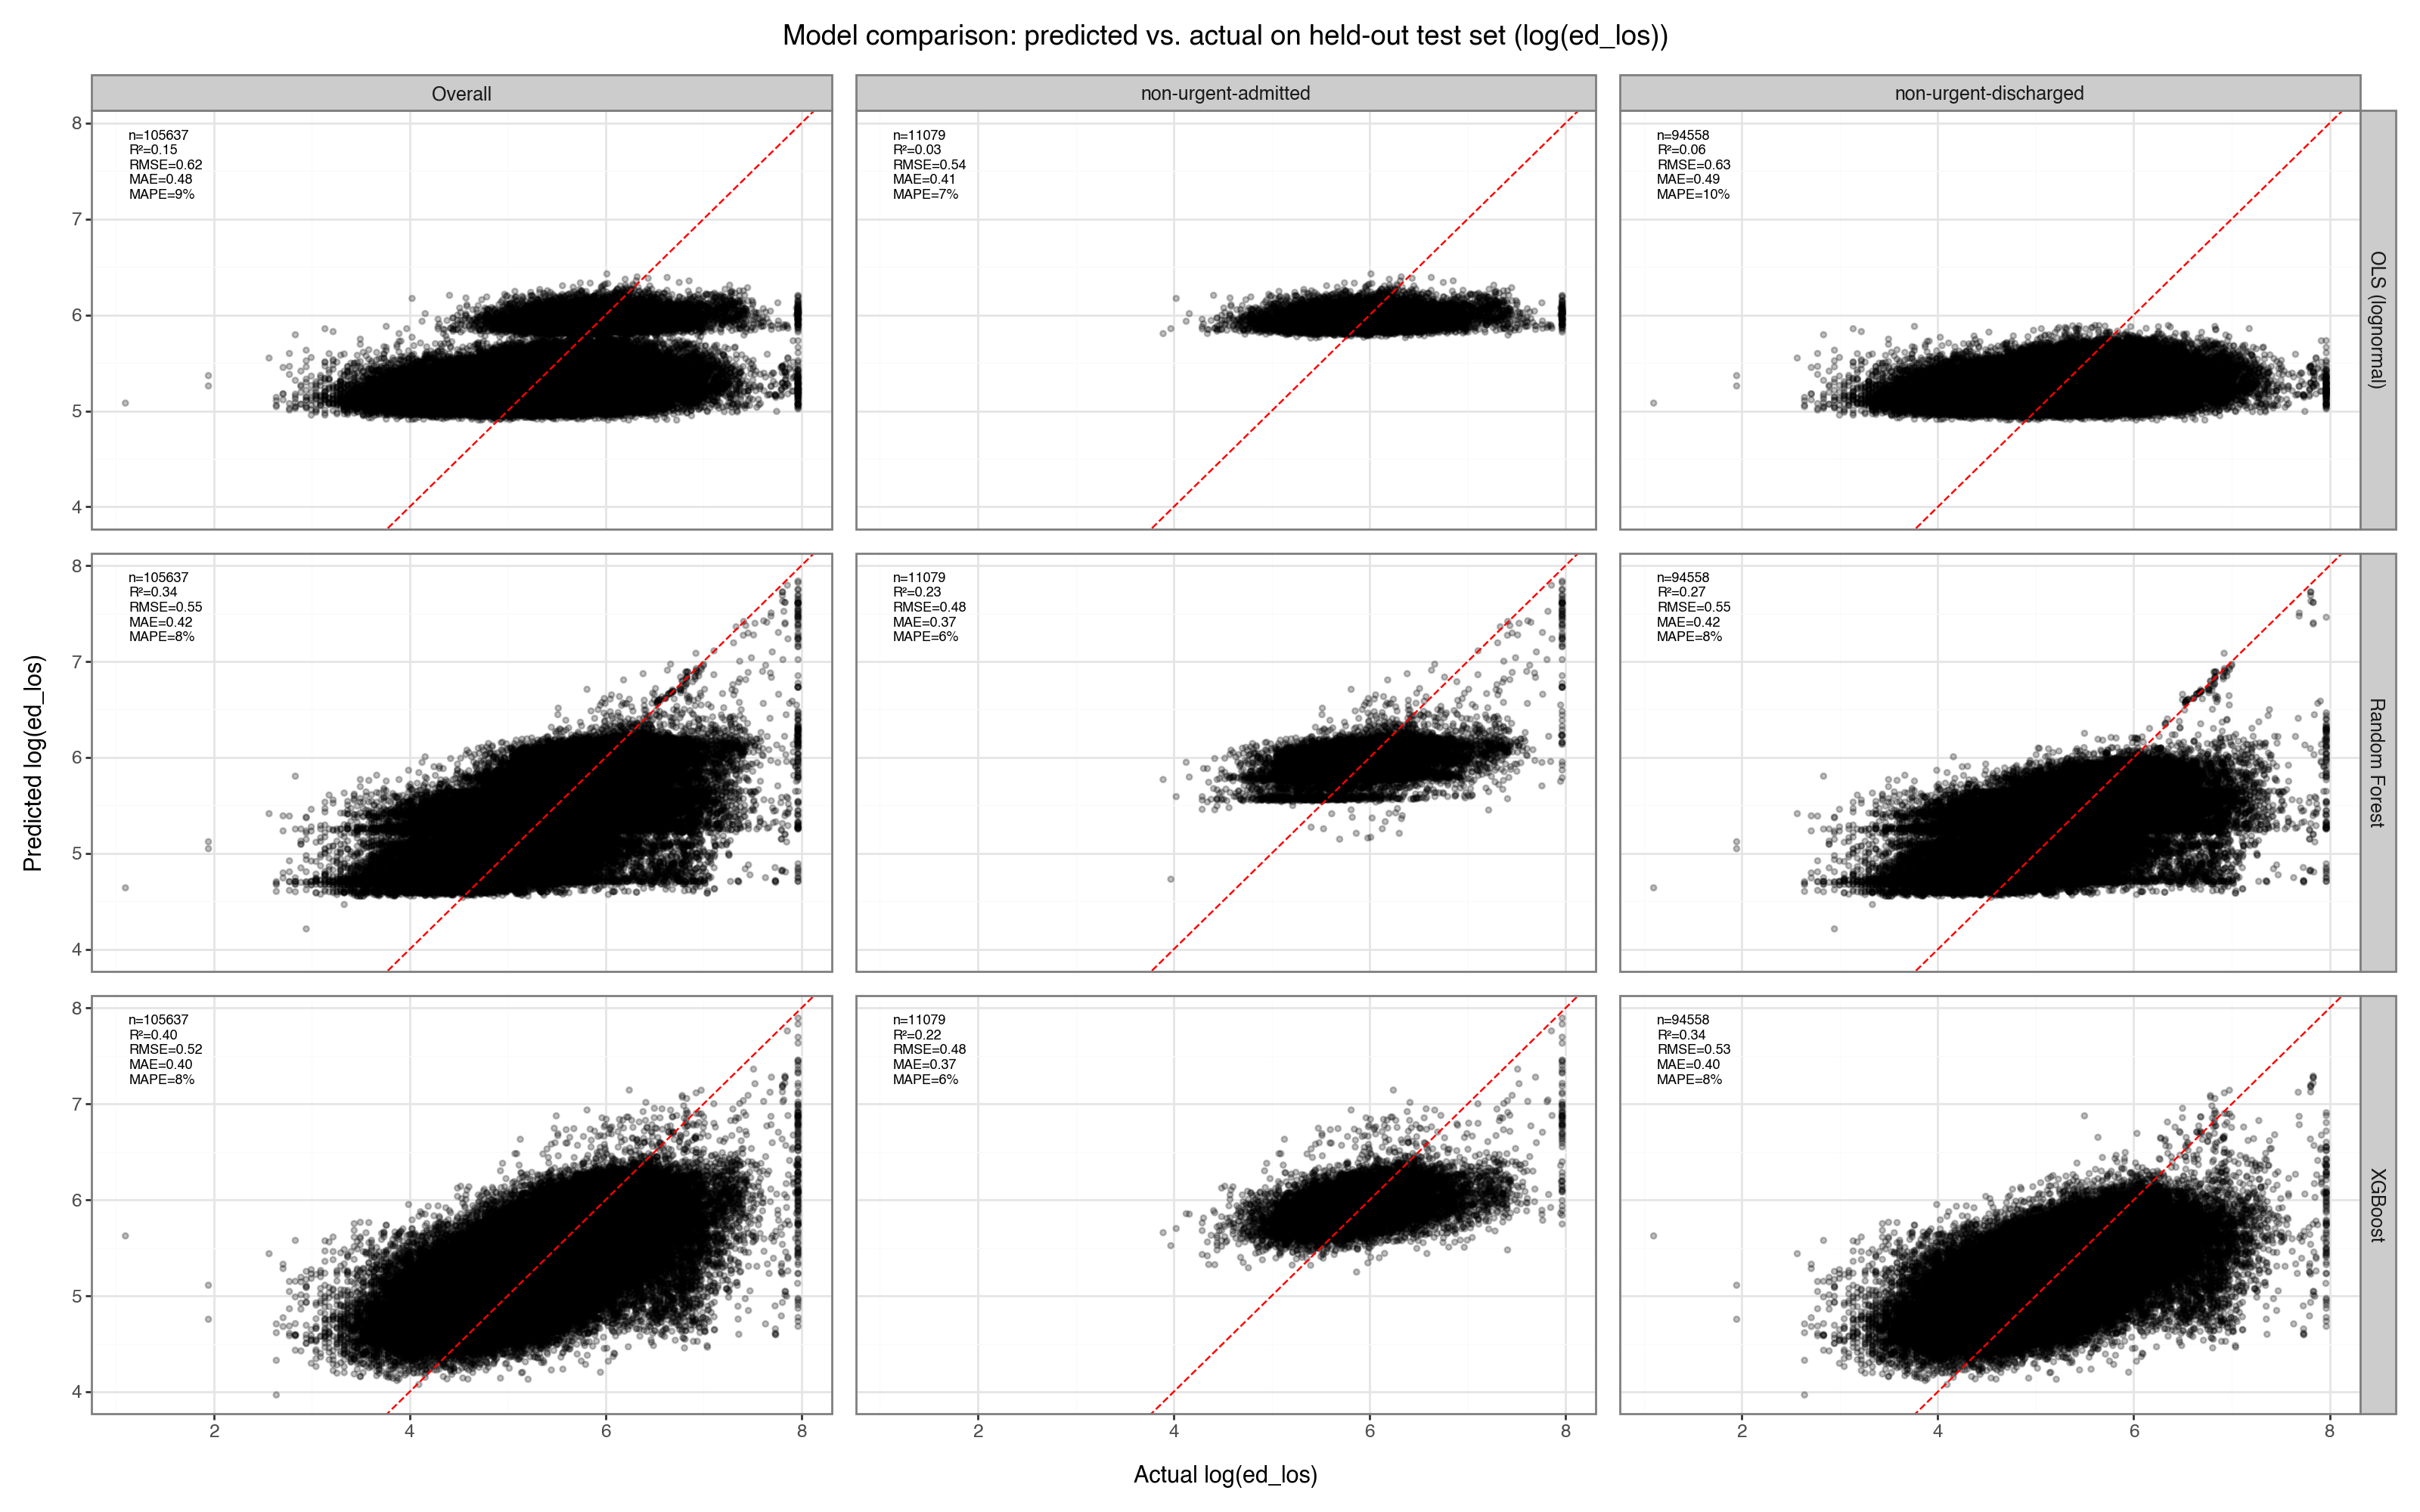

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_84117/1073469539.py:150: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


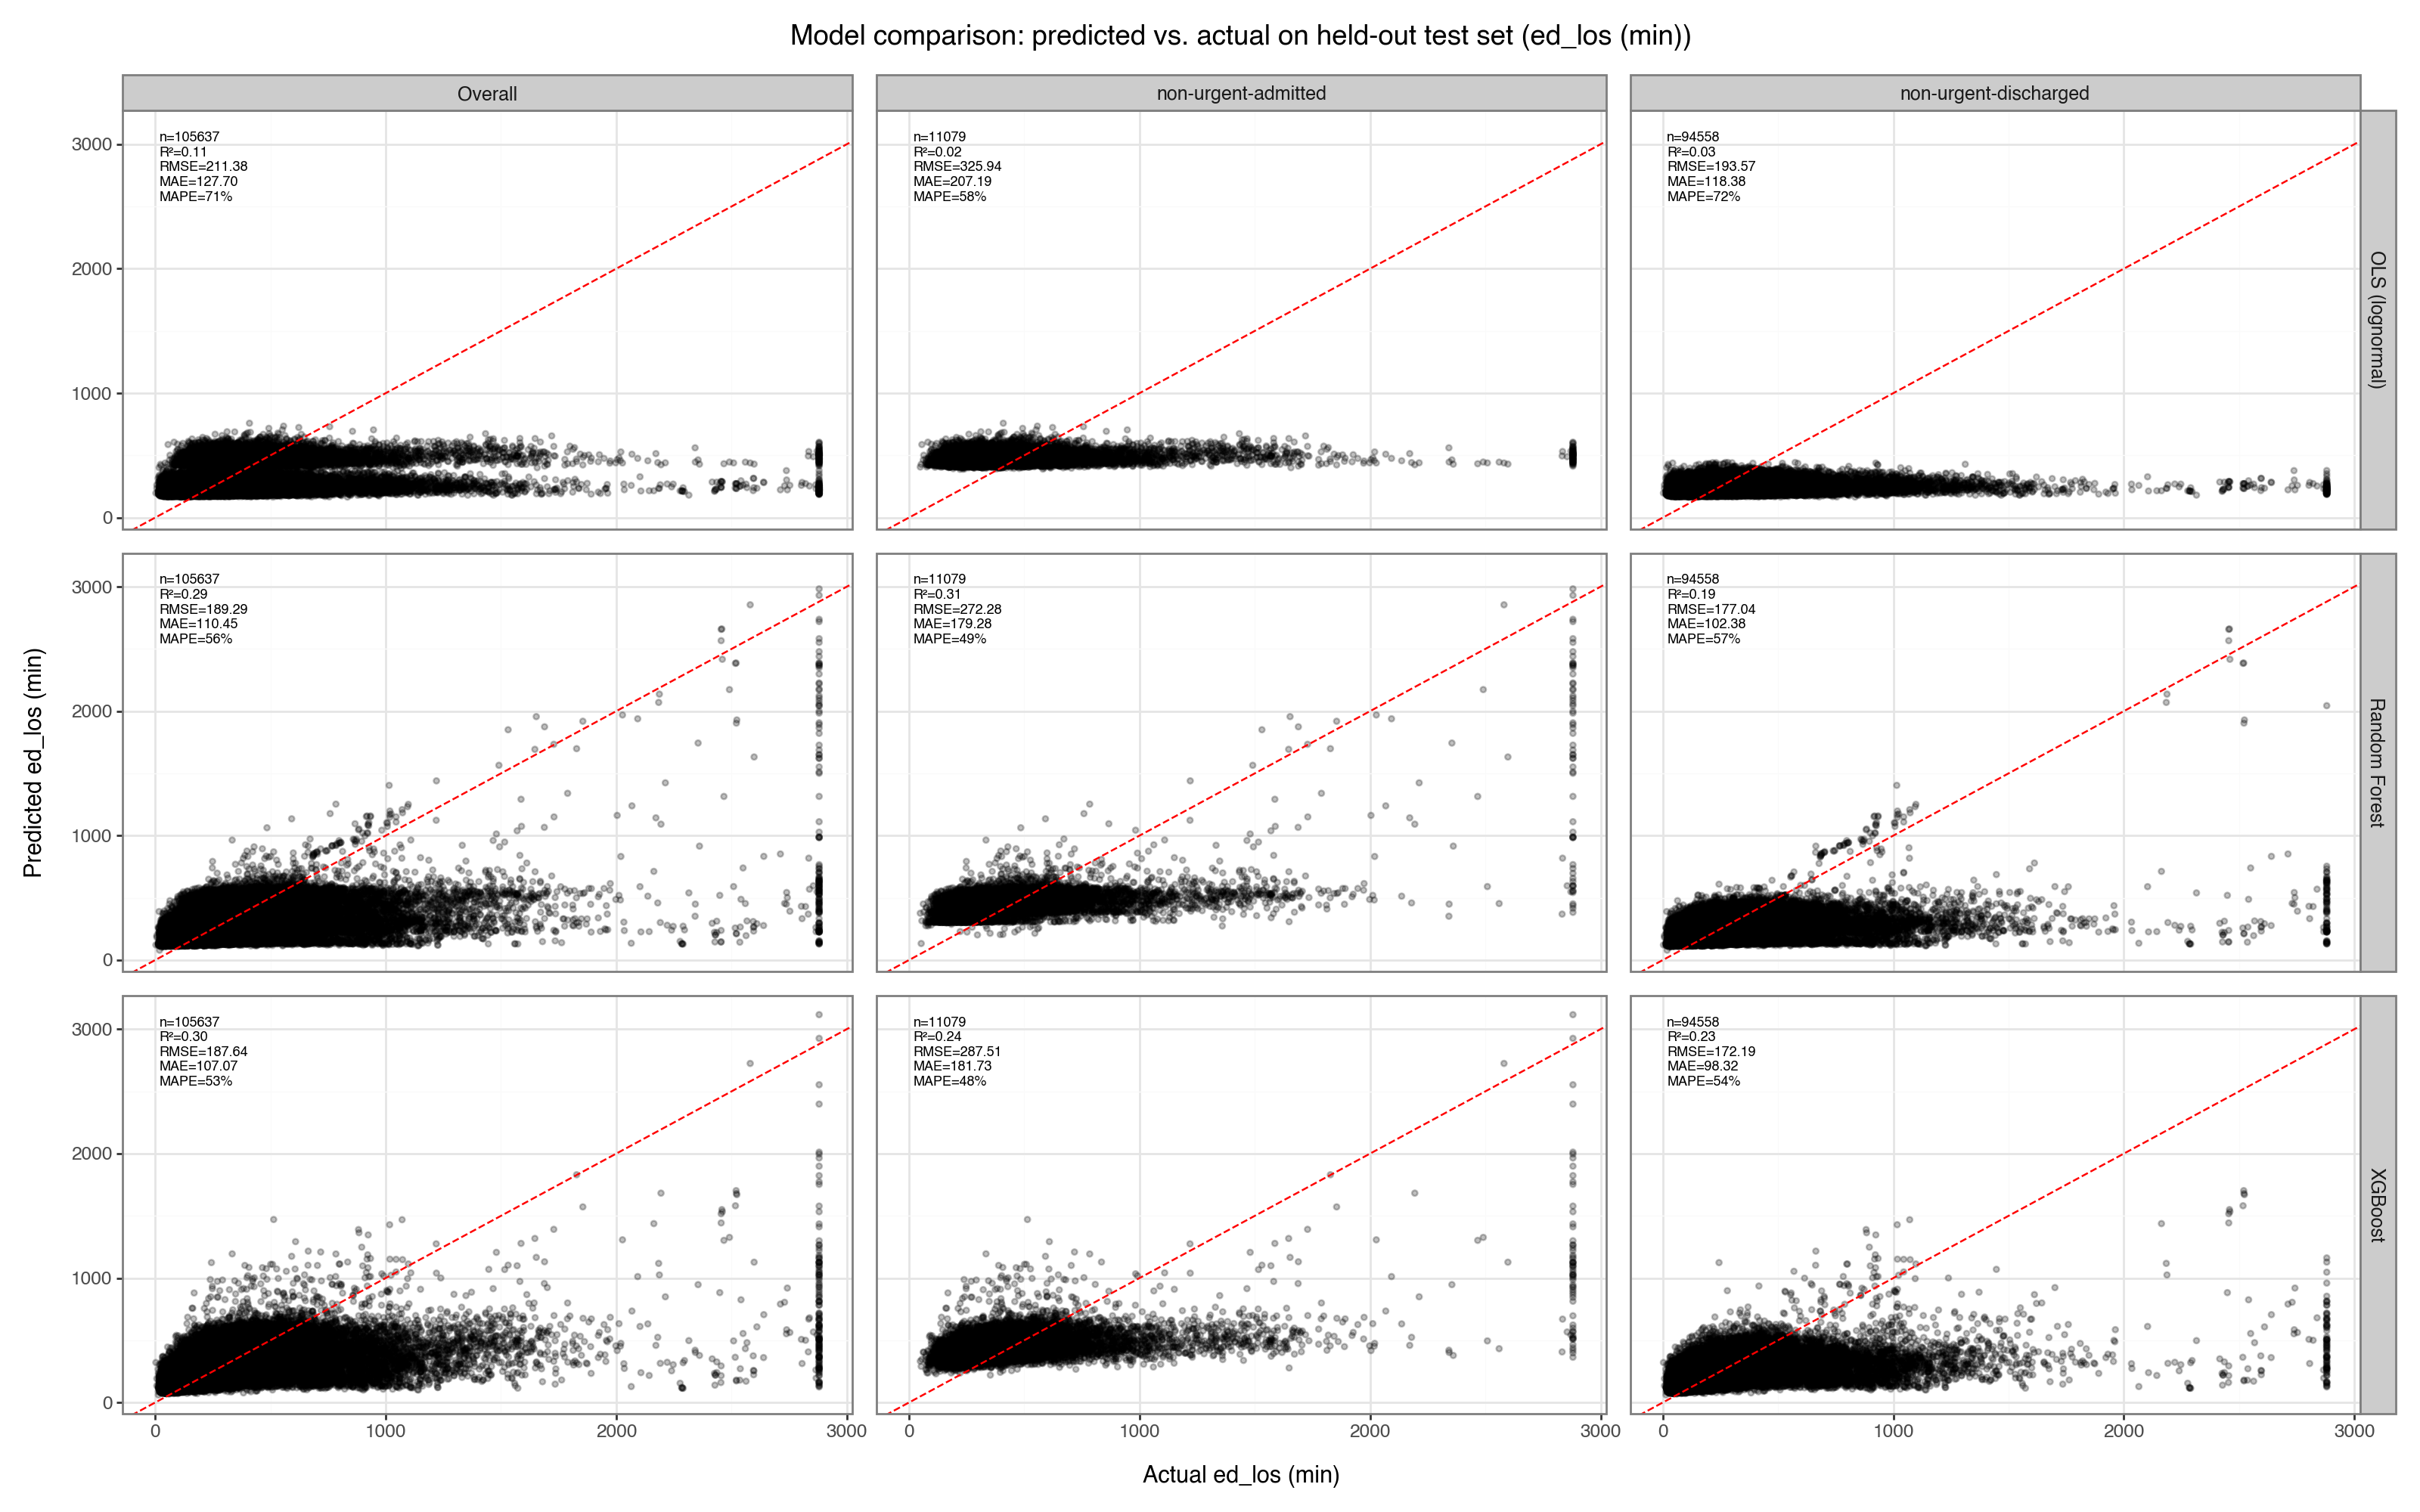

In [61]:
%matplotlib inline
import pandas as pd
import numpy as np
from plotnine import (
    ggplot, aes, geom_point, geom_abline, geom_text,
    facet_grid, labs, theme_bw, theme, element_text
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import statsmodels.formula.api as smf
import joblib

# ----------------------------------------------------------------------
# Load & prep data
# ----------------------------------------------------------------------
visit_timeline = pd.read_csv(save_filepath + 'visit-timeline.csv', index_col=0)

raw_visits = pd.read_csv(load_filepath + raw_file_name + ".csv", index_col=0, low_memory=False)

# Truncate LOS at 48 hours (1.1% of visits are longer than this)
visit_timeline['ed_los'] = np.where(visit_timeline['ed_los'] > 48 * 60, 48 * 60, visit_timeline['ed_los'])
visit_timeline['log_ed_los'] = np.log(visit_timeline['ed_los'])

FEATURE_COLS = (['visit_type', 'non-urgent-discharged', 'urgent-admitted', 'urgent-discharged', 'non-urgent-admitted', 'is_admitted'] + 
                    pre_binarised_predictors + categorical_predictors + continuous_predictors)

df = visit_timeline[['csn', 'visit_type', 'non-urgent-discharged', 'urgent-admitted', 'urgent-discharged', 'non-urgent-admitted', 'ed_los', 'log_ed_los', 'arrival']].merge(
    raw_visits[['csn', 'is_admitted'] + pre_binarised_predictors + categorical_predictors + continuous_predictors], on='csn', how='inner')

# Single train/test split shared across all models, for a fair comparison (chronological as before)
[X_train, X_test, y_train, y_test, csn_train, csn_test] = joblib.load(save_filepath+"outputs/split.joblib")
train_df, test_df = df.merge(csn_train, on='csn', how='inner'), df.merge(csn_train, on='csn', how='inner')

train_df.to_csv(save_filepath+'intermediate-files/ed-los-train-df.csv')
test_df.to_csv(save_filepath+'intermediate-files/ed-los-test-df.csv')

# One-hot encoded feature matrices for the sklearn-style models
X_train = pd.get_dummies(train_df[FEATURE_COLS], columns=['visit_type'] + categorical_predictors, drop_first=False)
X_test = pd.get_dummies(test_df[FEATURE_COLS], columns=['visit_type'] + categorical_predictors, drop_first=False)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)  # guard against unseen categories

y_train = train_df['log_ed_los']
y_test = test_df['log_ed_los']

# ----------------------------------------------------------------------
# Duan's smearing estimator: model-agnostic bias correction for
# exponentiating predictions of a log-transformed target.
# smearing factor = mean(exp(training residuals)); computed once per model
# using TRAINING residuals only, then applied to both train and test preds.
# ----------------------------------------------------------------------
def smearing_factor(y_true_log, y_pred_log):
    resid = y_true_log - y_pred_log
    return np.mean(np.exp(resid))

# ----------------------------------------------------------------------
# Fit each model on the SAME train split, predict on train + test
# ----------------------------------------------------------------------
preds = {}  # preds[model_name] = {'train': (log_pred, orig_pred), 'test': (...)}

# --- Model 1: OLS lognormal (with visit_type interactions) ---
formula = "log_ed_los ~ visit_type * (Q('non-urgent-discharged') + Q('urgent-admitted') + Q('urgent-discharged') + Q('non-urgent-admitted'))"
ols_results = smf.ols(formula, data=train_df).fit()

ols_train_log = ols_results.predict(train_df)
ols_test_log = ols_results.predict(test_df)
smear = smearing_factor(y_train, ols_train_log)
preds['OLS (lognormal)'] = {
    'train': (ols_train_log, np.exp(ols_train_log) * smear),
    'test': (ols_test_log, np.exp(ols_test_log) * smear),
}

# --- Model 2: XGBoost with random hyperparameters ---
xgb_model = XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=210226, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_train_log = xgb_model.predict(X_train)
xgb_test_log = xgb_model.predict(X_test)
smear = smearing_factor(y_train, xgb_train_log)
preds['XGBoost'] = {
    'train': (xgb_train_log, np.exp(xgb_train_log) * smear),
    'test': (xgb_test_log, np.exp(xgb_test_log) * smear),
}

# --- Model 3: Random Forest (fast, no boosting hyperparams to tune) ---
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=8, random_state=210221, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_train_log = rf_model.predict(X_train)
rf_test_log = rf_model.predict(X_test)
smear = smearing_factor(y_train, rf_train_log)
preds['Random Forest'] = {
    'train': (rf_train_log, np.exp(rf_train_log) * smear),
    'test': (rf_test_log, np.exp(rf_test_log) * smear),
}

# ----------------------------------------------------------------------
# Metrics
# ----------------------------------------------------------------------
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

    return pd.Series({'n': mask.sum(), 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})

# ----------------------------------------------------------------------
# Build a long comparison dataframe (test set only — this is the honest
# out-of-sample comparison) with an added "Overall" pseudo-group
# ----------------------------------------------------------------------
def build_comparison_df(scale='log'):
    rows = []
    for model_name, p in preds.items():
        log_pred, orig_pred = p['test']
        chunk = pd.DataFrame({
            'visit_type': test_df['visit_type'].values,
            'actual_log': y_test.values,
            'pred_log': log_pred,
            'actual_orig': test_df['ed_los'].values,
            'pred_orig': orig_pred,
        })
        chunk['model'] = model_name
        rows.append(chunk)
    long_df = pd.concat(rows, ignore_index=True)

    overall = long_df.copy()
    overall['visit_type'] = 'Overall'
    long_df = pd.concat([long_df, overall], ignore_index=True)

    actual_col, pred_col = ('actual_log', 'pred_log') if scale == 'log' else ('actual_orig', 'pred_orig')
    long_df = long_df.rename(columns={actual_col: 'actual', pred_col: 'pred'})
    return long_df[['model', 'visit_type', 'actual', 'pred']]

def plot_model_comparison(scale='log', scale_label=''):
    plot_df = build_comparison_df(scale=scale)

    metrics_df = (
        plot_df.groupby(['model', 'visit_type'])
        .apply(lambda g: compute_metrics(g['actual'], g['pred']))
        .reset_index()
    )

    lo = min(plot_df['actual'].min(), plot_df['pred'].min())
    hi = max(plot_df['actual'].max(), plot_df['pred'].max())
    pad = (hi - lo) * 0.05
    lo, hi = lo - pad, hi + pad

    metrics_df['label'] = metrics_df.apply(
        lambda r: (f"n={int(r['n'])}\nR²={r['R2']:.2f}\nRMSE={r['RMSE']:.2f}\n"
                    f"MAE={r['MAE']:.2f}\nMAPE={r['MAPE']:.0f}%"),
        axis=1
    )
    metrics_df['x'] = lo + (hi - lo) * 0.05
    metrics_df['y'] = hi - (hi - lo) * 0.05

    p = (
        ggplot(plot_df, aes(x='actual', y='pred'))
        + geom_point(alpha=0.25, size=1)
        + geom_abline(slope=1, intercept=0, color='red', linetype='dashed')
        + geom_text(
            data=metrics_df,
            mapping=aes(x='x', y='y', label='label'),
            ha='left', va='top', size=6.5, color='black'
        )
        + facet_grid('model ~ visit_type')
        + labs(
            x=f'Actual {scale_label}',
            y=f'Predicted {scale_label}',
            title=f'Model comparison: predicted vs. actual on held-out test set ({scale_label})'
        )
        + theme_bw()
        + theme(figure_size=(16, 10), strip_text=element_text(size=9))
    )
    return p

# --- Log scale ---
p_log = plot_model_comparison(scale='log', scale_label='log(ed_los)')
p_log.show()

# --- Original scale ---
p_orig = plot_model_comparison(scale='orig', scale_label='ed_los (min)')
p_orig.show()




When the same information is given to XGBoost as the lognormal model, the performance is essentially the same; the design doesn't help at all (which makes sense).
Even giving a fair amount of visit information (in a structured way) also doesn't really help.

Two options: we can use the RNN approach; or we can find another outcome. The one that immediately springs to mind is crowding itself: knowing the composition of an ED, can we predict crowding in 1 hour from now?/2 hours, 24 hours?

TRY THAT FIRST.

In [13]:
%matplotlib inline

#Load crowding history.
crowding_history = pd.read_csv(save_filepath+'crowding-history.csv', index_col=0)

#Fill in the blanks for timestamps at which no event occurred.
#If there were events at 1 and 3 mins, then we know what the system looked like at 2 mins (it was the same as 1).
all_timestamps = list(range(crowding_history['timestamp'].astype(int).min(), crowding_history['timestamp'].astype(int).max()+1))
crowding_history = pd.DataFrame({
    'timestamp':all_timestamps
}).merge(crowding_history, on='timestamp', how='left').ffill()

#Sum the number of people waiting.
crowding_history['crowding'] = crowding_history['non-urgent-discharged'] + crowding_history['urgent-discharged'] + crowding_history['non-urgent-admitted'] + crowding_history['urgent-admitted']

# p = (ggplot(crowding_history, aes(x='crowding'))
#         + geom_density(alpha=0.4)
#         + scale_x_log10()
#         + labs(title='Crowding', x='Crowding', y='Density', fill='')
#         + theme_minimal()
#         + theme(figure_size=(5, 3.5), plot_title=element_text(size=11))
#     )
# p.show()

#Define windows of interest
windows = [2, 4, 6, 12]
outcome_names = ['crowding_in_2_hours', 'crowding_in_4_hours', 'crowding_in_6_hours', 'crowding_in_12_hours']

#Extract crowding in the future, if known
for window, outcome_name in zip(windows, outcome_names):
    subdf = pd.DataFrame({
        'focal_timestamp':crowding_history['timestamp'],
        'prediction_timestamp':crowding_history['timestamp']+window*60,
    })
    subdf = subdf.merge(
        crowding_history[['timestamp', 'crowding']],
        left_on='prediction_timestamp', right_on='timestamp'
    )[['focal_timestamp', 'crowding']].rename(columns={
        'focal_timestamp':'timestamp',
        'crowding':outcome_name})
    crowding_history = crowding_history.merge(subdf, on='timestamp', how='left')

#Lift these at the original timestamps
original_timestamps = pd.read_csv(save_filepath+'crowding-history.csv', index_col=0)[['timestamp']]
crowding_history = crowding_history.merge(original_timestamps, on='timestamp', how='inner')

crowding_history.to_csv(save_filepath+'crowding-in-future.csv')


crowding_in_2_hours
crowding_in_4_hours
crowding_in_6_hours
crowding_in_12_hours


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_84117/4075978637.py:122: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


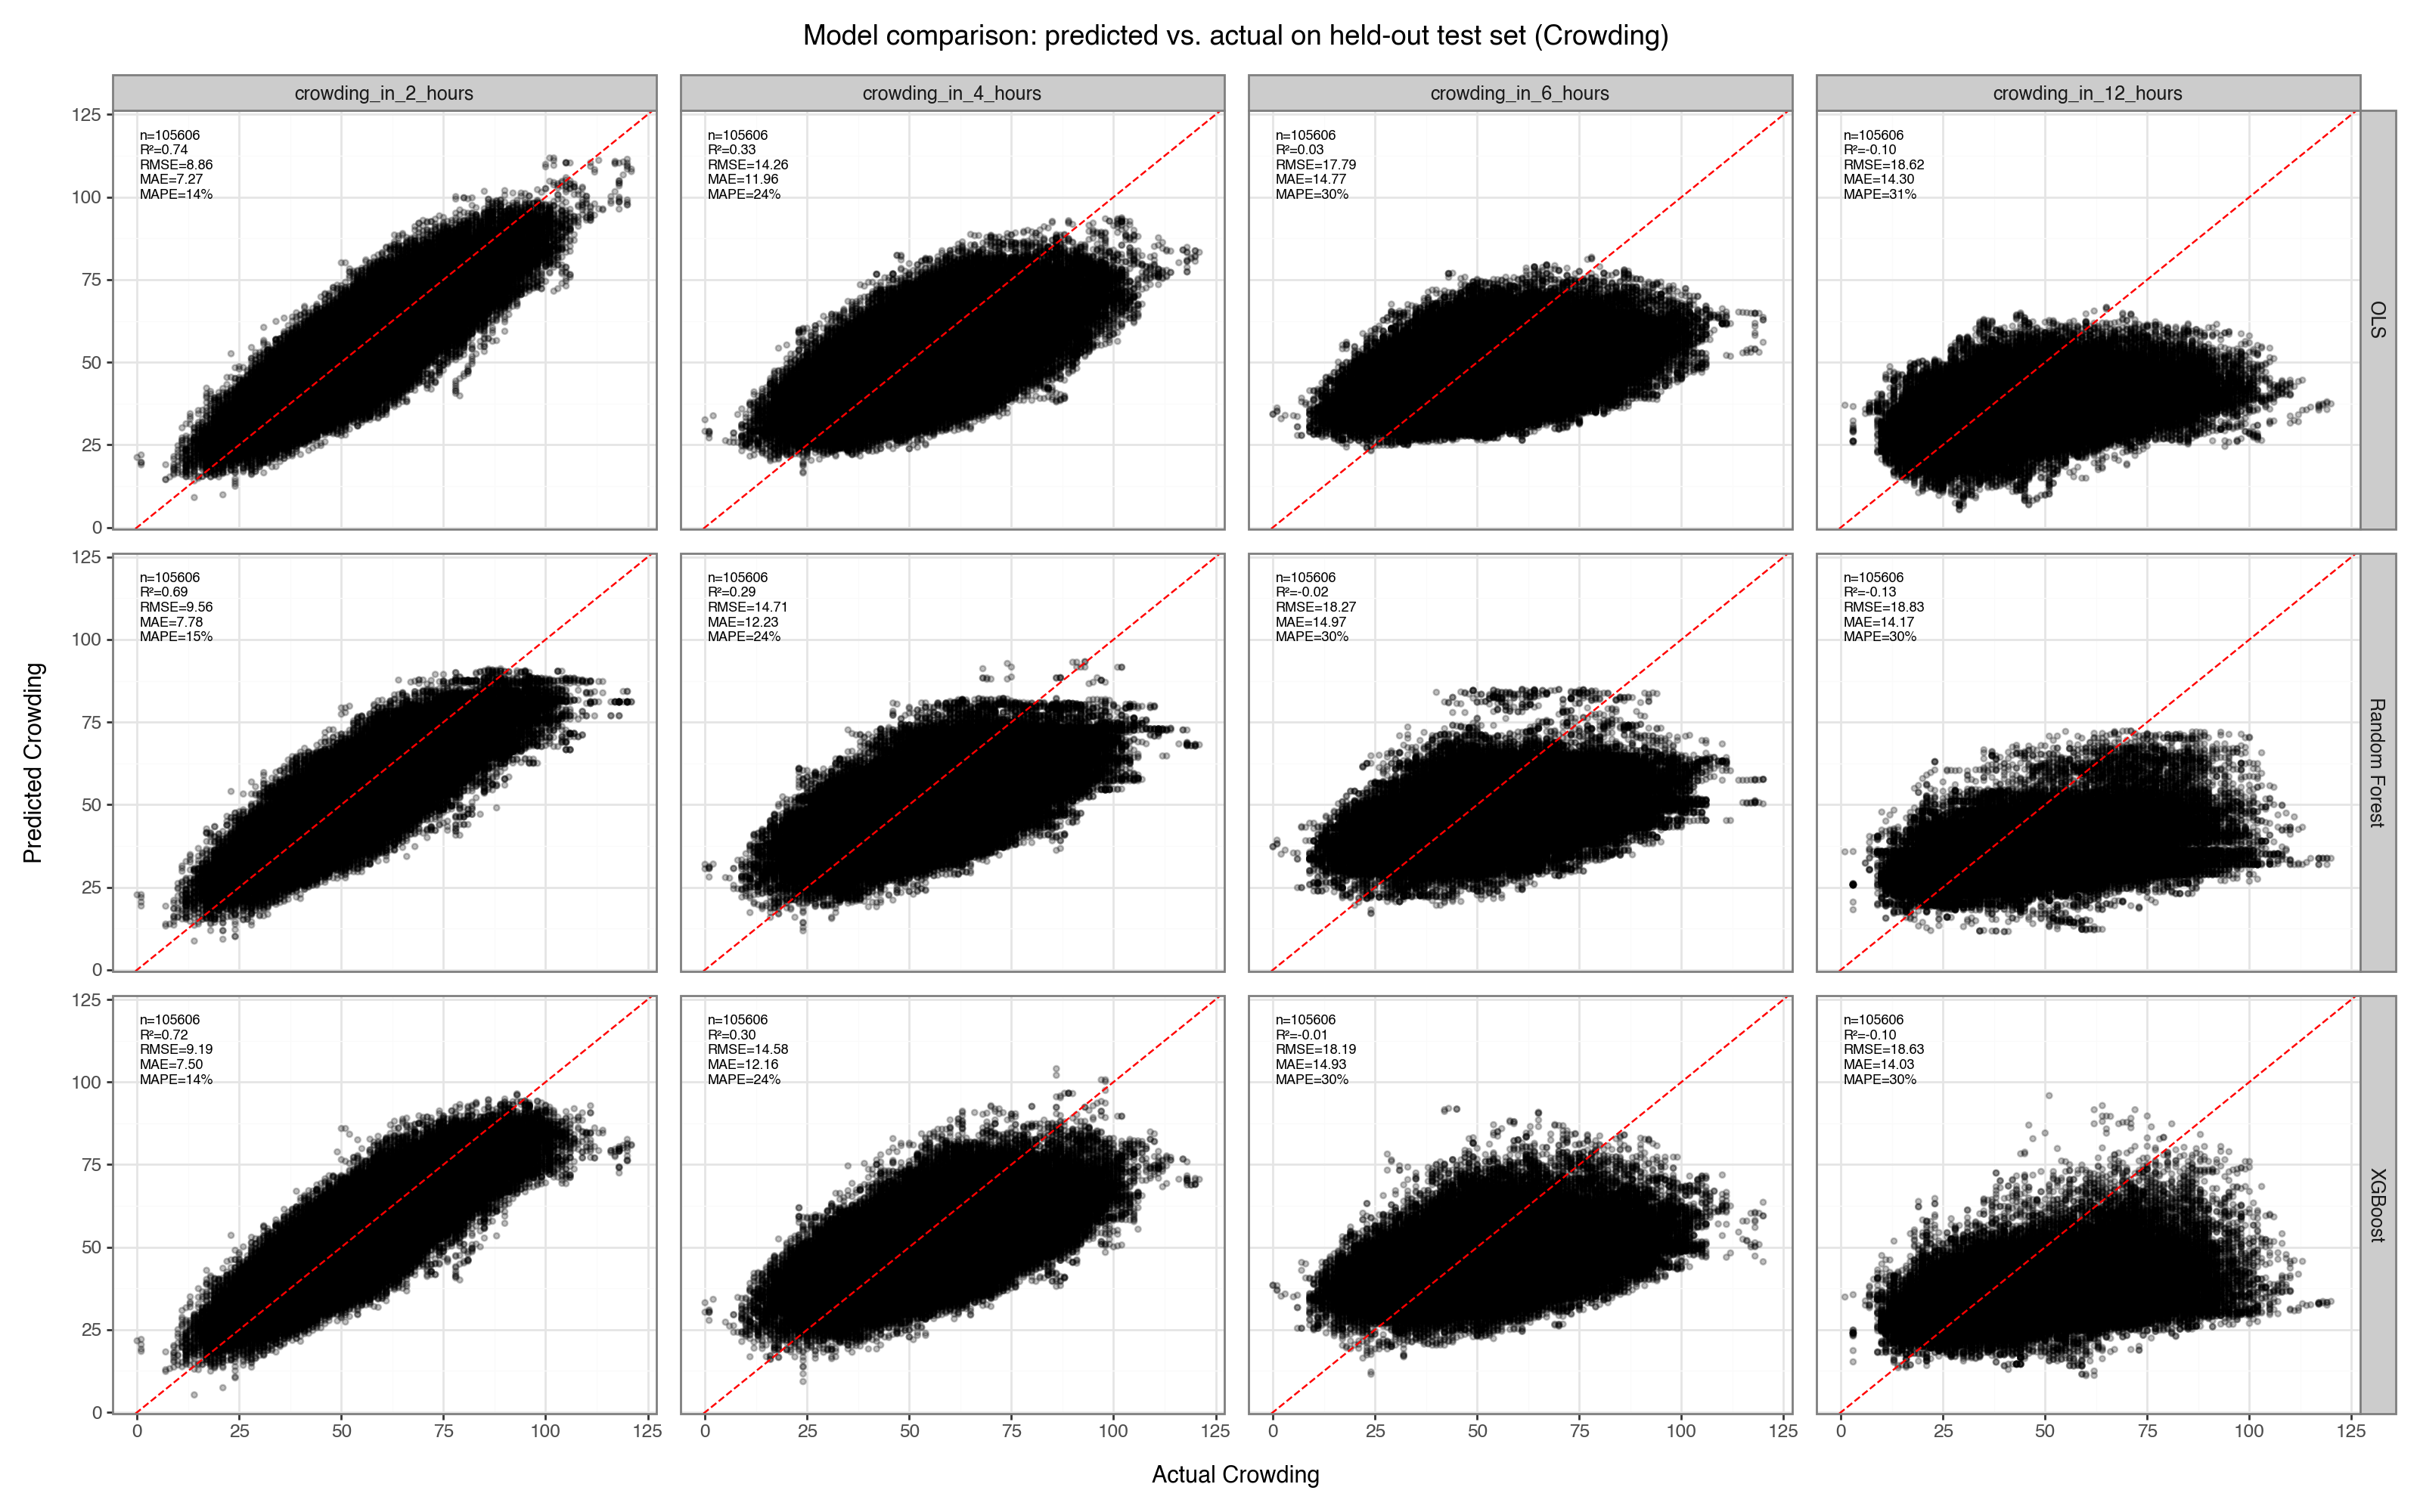

In [62]:
%matplotlib inline
import pandas as pd
import numpy as np
from plotnine import (
    ggplot, aes, geom_point, geom_abline, geom_text,
    facet_grid, labs, theme_bw, theme, element_text
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import statsmodels.formula.api as smf
import joblib

# ----------------------------------------------------------------------
# Load & prep data
# ----------------------------------------------------------------------
crowding = pd.read_csv(save_filepath + 'crowding-in-future.csv', index_col=0)
outcome_names = ['crowding_in_2_hours', 'crowding_in_4_hours', 'crowding_in_6_hours', 'crowding_in_12_hours']

FEATURE_COLS = ['non-urgent-discharged', 'urgent-admitted', 'urgent-discharged', 'non-urgent-admitted']

# Shared train/test split (chronological, as before)
[_, _, _, _, csn_train, csn_test] = joblib.load(save_filepath + "outputs/split.joblib")

visit_timeline = pd.read_csv(save_filepath + 'visit-timeline.csv', index_col=0)[['csn', 'arrival']].rename(columns={'arrival': 'timestamp'})
crowding = crowding.merge(visit_timeline, on='timestamp', how='inner')

# FIX: test_df must merge on csn_test, not csn_train
train_df = crowding.merge(csn_train, on='csn', how='inner')
test_df = crowding.merge(csn_test, on='csn', how='inner')

X_train_base = train_df[FEATURE_COLS]
X_test_base = test_df[FEATURE_COLS]
X_test_base = X_test_base.reindex(columns=X_train_base.columns, fill_value=0)

# Record predictions per outcome/model
preds = {}

for outcome in outcome_names:
    y_train_full = train_df[outcome]
    y_test_full = test_df[outcome]

    # Mask used ONLY for fitting (models can't train on NaN targets)
    train_mask = ~y_train_full.isna()
    X_train, y_train = X_train_base[train_mask], y_train_full[train_mask]

    print(outcome)
    subpreds = {}

    # --- Model 1: OLS ---
    formula = outcome + " ~ Q('non-urgent-discharged') + Q('urgent-admitted') + Q('urgent-discharged') + Q('non-urgent-admitted')"
    ols_results = smf.ols(formula, data=train_df[train_mask]).fit()
    ols_train = ols_results.predict(train_df)
    ols_test = ols_results.predict(test_df)
    subpreds['OLS'] = {'train': ols_train, 'test': ols_test}

    # --- Model 2: XGBoost ---
    xgb_model = XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=210226, n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    # FIX: predict on the FULL, unmasked feature frames so lengths match
    # test_df/train_df exactly, for every model, regardless of NaNs in y.
    xgb_train = xgb_model.predict(X_train_base)
    xgb_test = xgb_model.predict(X_test_base)
    subpreds['XGBoost'] = {'train': xgb_train, 'test': xgb_test}

    # --- Model 3: Random Forest ---
    rf_model = RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=210221, n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    rf_train = rf_model.predict(X_train_base)
    rf_test = rf_model.predict(X_test_base)
    subpreds['Random Forest'] = {'train': rf_train, 'test': rf_test}

    preds[outcome] = subpreds

# ----------------------------------------------------------------------
# Metrics (NaNs in actual/predicted are dropped pairwise here)
# ----------------------------------------------------------------------
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

    return pd.Series({'n': mask.sum(), 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})

# ----------------------------------------------------------------------
# Build long comparison dataframe (test set only)
# ----------------------------------------------------------------------
def build_comparison_df():
    rows = []
    for outcome, subpreds in preds.items():
        for model_name, p in subpreds.items():
            # test_df[outcome].values and p['test'] are now guaranteed
            # to be the same length for every model.
            chunk = pd.DataFrame({
                'actual': test_df[outcome].values,
                'pred': p['test'],
            })
            chunk['model'] = model_name
            chunk['outcome'] = outcome
            rows.append(chunk)
    long_df = pd.concat(rows, ignore_index=True)
    long_df['outcome'] = pd.Categorical(long_df['outcome'], categories=outcome_names, ordered=True)
    return long_df

def plot_model_comparison(scale_label=''):
    plot_df = build_comparison_df()

    metrics_df = (
        plot_df.groupby(['model', 'outcome'], observed=True)
        .apply(lambda g: compute_metrics(g['actual'], g['pred']))
        .reset_index()
    )
    # FIX: quote the column name — 'outcome' was previously the leaked loop variable
    metrics_df['outcome'] = pd.Categorical(metrics_df['outcome'], categories=outcome_names, ordered=True)

    lo = min(plot_df['actual'].min(), plot_df['pred'].min())
    hi = max(plot_df['actual'].max(), plot_df['pred'].max())
    pad = (hi - lo) * 0.05
    lo, hi = lo - pad, hi + pad

    metrics_df['label'] = metrics_df.apply(
        lambda r: (f"n={int(r['n'])}\nR²={r['R2']:.2f}\nRMSE={r['RMSE']:.2f}\n"
                    f"MAE={r['MAE']:.2f}\nMAPE={r['MAPE']:.0f}%"),
        axis=1
    )
    metrics_df['x'] = lo + (hi - lo) * 0.05
    metrics_df['y'] = hi - (hi - lo) * 0.05

    p = (
        ggplot(plot_df, aes(x='actual', y='pred'))
        + geom_point(alpha=0.25, size=1)
        + geom_abline(slope=1, intercept=0, color='red', linetype='dashed')
        + geom_text(
            data=metrics_df,
            mapping=aes(x='x', y='y', label='label'),
            ha='left', va='top', size=6.5, color='black'
        )
        + facet_grid('model ~ outcome')
        + labs(
            x=f'Actual {scale_label}',
            y=f'Predicted {scale_label}',
            title=f'Model comparison: predicted vs. actual on held-out test set ({scale_label})'
        )
        + theme_bw()
        + theme(figure_size=(16, 10), strip_text=element_text(size=9))
    )
    return p

p_orig = plot_model_comparison(scale_label='Crowding')
p_orig.show()

OK, this also probably isn't good enough. RNNs it is, I suppose.


In [29]:
train_df = pd.read_csv(save_filepath+'intermediate-files/ed-los-train-df.csv', index_col=0)
train_df

,csn,visit_type,non-urgent-discharged,urgent-admitted,urgent-discharged,non-urgent-admitted,ed_los,log_ed_los,arrival,is_admitted,...,mean_pain,mean_rr,mean_sbp,mean_sp_o2,min_dbp,min_hr,min_pain,min_rr,min_sbp,min_sp_o2
0,6124202846,non-urgent-discharged,1.0,0.0,0.0,0.0,113.0,4.727388,0.0,0,...,NaN,22.0,NaN,NaN,NaN,84.0,NaN,22.0,NaN,NaN
1,6124202852,non-urgent-discharged,2.0,0.0,0.0,0.0,678.0,6.519147,46.0,0,...,9.0,20.0,120.0,100.0,81.0,120.0,9.0,20.0,120.0,100.0
2,6124202854,non-urgent-discharged,3.0,0.0,0.0,0.0,132.0,4.882802,51.0,0,...,0.0,18.0,133.0,100.0,81.0,110.0,0.0,18.0,133.0,100.0
3,6124202859,non-urgent-discharged,4.0,0.0,0.0,0.0,157.0,5.056246,68.0,0,...,NaN,32.0,118.0,100.0,60.0,118.0,NaN,32.0,118.0,100.0
4,6124202864,non-urgent-discharged,5.0,0.0,0.0,0.0,218.0,5.384495,84.0,0,...,NaN,22.0,108.0,94.0,62.0,120.0,NaN,22.0,108.0,94.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105632,6134229890,non-urgent-discharged,16.0,10.0,14.0,5.0,39.0,3.663562,1614096.0,0,...,4.0,24.0,101.0,NaN,69.0,86.0,4.0,24.0,101.0,NaN
105633,6134229905,non-urgent-discharged,16.0,9.0,13.0,5.0,144.0,4.969813,1614112.0,0,...,NaN,28.0,110.0,100.0,71.0,80.0,NaN,28.0,110.0,100.0
105634,6134229925,non-urgent-discharged,13.0,10.0,12.0,5.0,313.0,5.746203,1614168.0,0,...,8.0,20.0,111.0,NaN,80.0,84.0,8.0,20.0,111.0,NaN
105635,6134229926,non-urgent-discharged,14.0,10.0,12.0,5.0,133.0,4.890349,1614172.0,0,...,NaN,40.0,97.0,97.0,56.0,132.0,NaN,40.0,97.0,97.0


Have vibe-coded an LSTM:

In [76]:
"""
LSTM for ED Length-of-Stay prediction, modeled as a causal sequence of visits
ordered by arrival time (captures crowding/queue dynamics via hidden state).

Assumptions baked into this script (adjust to your data):
  - One dataframe per site, already sorted (or sortable) by arrival time.
    If you have multiple sites, run this pipeline separately per site, or
    add a site_id categorical feature AND reset hidden state at site boundaries.
  - timestamp_col is a NUMERIC "minutes since first arrival" index, not a
    datetime. If you also know the real calendar datetime of the first
    arrival, set Config.reference_start_datetime to reconstruct hour-of-day /
    day-of-week cyclical features; otherwise those are skipped automatically.
  - Target: LOS in minutes -> log1p-transformed for training (MSE loss on
    the log scale, back-transformed via expm1 for reporting).
  - Retrospective setting: fine to use disposition/admission status as a
    feature, since prediction is made after discharge, not at triage.
  - categorical_predictors are TEXT/STRING categories and need explicit
    integer encoding (fit on train_df only, with an "unseen" fallback bucket
    for categories that only appear in test_df).
  - pre_binarised_predictors and is_admitted are already 0/1 binary flags -
    these are treated as NUMERIC inputs, not embedded. Embedding a 2-state
    variable adds parameters for no benefit; a raw 0/1 (or its z-score)
    already represents it fully.
  - Truncated BPTT: sequences are chunked into windows; the LSTM hidden
    state is carried across consecutive windows of the same sequence and
    detached between windows to cap the backprop graph size.

Fill in continuous_predictors / categorical_predictors / pre_binarised_predictors
and the file paths in the RUN section at the bottom, then execute.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# --------------------------------------------------------------------------
# CONFIG - built dynamically from your predictor lists once train_df is loaded.
# Call build_config(train_df, continuous_predictors, categorical_predictors,
# pre_binarised_predictors) rather than editing a hardcoded class - see RUN
# section at the bottom.
# --------------------------------------------------------------------------
class Config:
    timestamp_col = "arrival"
    los_col = "ed_los"

    # If you know the real-world calendar datetime of the very first arrival,
    # set it here (e.g. pd.Timestamp("2021-01-04 07:12:00")) and hour-of-day /
    # day-of-week cyclical features will be reconstructed automatically.
    # Leave as None to skip those features (inter-arrival gap is still used).
    reference_start_datetime = None

    # These are populated by build_config(); placeholders here just document
    # the shape expected.
    numeric_cols = []          # continuous predictors + binary flags + is_admitted
    categorical_cols = {}      # {col: cardinality including the +1 unknown bucket}
    embedding_dims = {}        # {col: chosen embedding size, < cardinality}
    time_cols = []             # populated at feature-engineering time

    hidden_dim = 128
    lstm_layers = 2
    dropout = 0.0

    window_len = 10      # visits per truncated-BPTT window
    window_stride = 10   # non-overlapping; reduce for overlap
    batch_size = 8

    lr = 1e-3
    epochs = 20
    device = "cuda" if torch.cuda.is_available() else "cpu"


def build_config(train_df, continuous_predictors, categorical_predictors,
                  pre_binarised_predictors, is_admitted_col="is_admitted",
                  timestamp_col="arrival", los_col="ed_los",
                  reference_start_datetime=None):
    """
    Constructs a Config instance from your predictor lists.

    - continuous_predictors, pre_binarised_predictors, and is_admitted are all
      routed to numeric_cols (binary flags need no embedding).
    - categorical_predictors are TEXT columns -> get integer-encoded (see
      fit_categorical_encoders) and go through embeddings, sized well below
      their cardinality rather than equal to it.
    """
    cfg = Config()
    cfg.timestamp_col = timestamp_col
    cfg.los_col = los_col
    cfg.reference_start_datetime = reference_start_datetime

    cfg.numeric_cols = list(continuous_predictors) + list(pre_binarised_predictors) + [is_admitted_col]

    # Cardinality is set once encoders are fit (train-only) - see prepare_train_test.
    # Placeholder here; overwritten in prepare_train_test after encoding.
    cfg.categorical_cols = {col: train_df[col].nunique() + 1 for col in categorical_predictors}
    cfg.embedding_dims = {col: min(50, (n + 1) // 2) for col, n in cfg.categorical_cols.items()}

    return cfg


# --------------------------------------------------------------------------
# Categorical encoding: text -> integer codes, fit on train_df ONLY.
# Index 0 is reserved for "unseen/unknown" (categories only in test_df).
# --------------------------------------------------------------------------
def fit_categorical_encoders(train_df: pd.DataFrame, cat_col_names: list) -> dict:
    encoders = {}
    for col in cat_col_names:
        categories = sorted(train_df[col].dropna().astype(str).unique().tolist())
        encoders[col] = {cat: i + 1 for i, cat in enumerate(categories)}  # 0 reserved for unknown
    return encoders


def apply_categorical_encoders(df: pd.DataFrame, cat_col_names: list, encoders: dict) -> pd.DataFrame:
    df = df.copy()
    for col in cat_col_names:
        df[col] = df[col].astype(str).map(encoders[col]).fillna(0).astype(np.int64)
    return df


# --------------------------------------------------------------------------
# Feature engineering
#
# Split into fit_scaler (train_df only) + apply_features (any df), so
# normalization stats and outlier caps never leak from test into train.
# --------------------------------------------------------------------------
def add_time_and_target_features(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Deterministic features that don't need fitting: safe to apply to any split.

    timestamp_col is a numeric minutes-since-first-arrival index (not a
    datetime). Cyclical hour-of-day / day-of-week features are only added if
    cfg.reference_start_datetime is set; otherwise cfg.time_cols stays empty
    and the model relies on inter-arrival gap alone for temporal context.
    """
    df = df.sort_values(cfg.timestamp_col).reset_index(drop=True)

    if cfg.reference_start_datetime is not None:
        real_ts = cfg.reference_start_datetime + pd.to_timedelta(df[cfg.timestamp_col], unit="m")
        hour = real_ts.dt.hour + real_ts.dt.minute / 60.0
        df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
        df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
        dow = real_ts.dt.dayofweek
        df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
        cfg.time_cols = ["hour_sin", "hour_cos", "dow_sin"]
    else:
        cfg.time_cols = []

    # timestamp_col is already in minutes, so a simple diff gives the gap directly
    df["inter_arrival_gap"] = df[cfg.timestamp_col].diff().fillna(0)

    df["log_los"] = np.log1p(df[cfg.los_col].clip(lower=0))
    return df


def diagnose_missingness(df: pd.DataFrame, numeric_cols: list, los_col: str) -> None:
    """
    Prints NaN/Inf counts per numeric column and the target. Run this on
    train_df and test_df BEFORE training - an LSTM will silently produce
    NaN loss for the entire run if even one row has a missing/infinite value,
    since the hidden state carries the NaN forward through the whole sequence.
    """
    print("--- missingness / infinity check ---")
    any_found = False
    for col in numeric_cols + [los_col]:
        n_nan = df[col].isna().sum()
        n_inf = int(np.isinf(df[col].to_numpy(dtype=float, na_value=0.0)).sum())
        if n_nan or n_inf:
            any_found = True
            print(f"  {col}: {n_nan} NaN, {n_inf} Inf (of {len(df)} rows)")
    if not any_found:
        print("  none found")
    print("-------------------------------------")


def fit_scaler(train_df: pd.DataFrame, cfg: Config) -> dict:
    """
    Compute normalization stats, an imputation value, and the outlier cap
    from train_df ONLY. Median (not mean) is used for imputation since it's
    robust to the same skew/outliers the gap cap is protecting against.
    """
    stats = {}
    gap_cap = train_df["inter_arrival_gap"].quantile(0.99)
    stats["inter_arrival_gap_cap"] = gap_cap

    capped_gap = train_df["inter_arrival_gap"].clip(upper=gap_cap)
    for col, series in [*[(c, train_df[c]) for c in cfg.numeric_cols],
                        ("inter_arrival_gap", capped_gap)]:
        clean = series.replace([np.inf, -np.inf], np.nan)
        stats[col] = {
            "mu": clean.mean(),
            "sigma": clean.std() + 1e-6,
            "median": clean.median(),
        }
    return stats


def apply_features(df: pd.DataFrame, cfg: Config, scaler: dict) -> pd.DataFrame:
    """
    Apply train-fit normalization/capping/imputation to any split.

    For each numeric column: infinities are treated as missing, missing
    values are imputed with the TRAIN median (never a value computed on the
    split being processed), and a same-named "<col>_missing" indicator flag
    is added so the model can still use the fact that a value was missing
    (often informative in clinical data - e.g. a vital not being taken can
    itself correlate with acuity) rather than just silently filling it in.

    Columns are assembled in dicts and joined once via pd.concat, instead of
    being inserted one at a time, to avoid DataFrame fragmentation.
    """
    df = df.copy()
    df["inter_arrival_gap"] = df["inter_arrival_gap"].clip(upper=scaler["inter_arrival_gap_cap"])

    new_cols = {}
    for col in cfg.numeric_cols + ["inter_arrival_gap"]:
        raw = df[col].replace([np.inf, -np.inf], np.nan)
        is_missing = raw.isna()
        imputed = raw.fillna(scaler[col]["median"])

        mu, sigma = scaler[col]["mu"], scaler[col]["sigma"]
        new_cols[col + "_z"] = (imputed - mu) / sigma

        # Skip a missing-indicator column for inter_arrival_gap - it's
        # already guaranteed non-null (first row is filled with 0 upstream).
        if col != "inter_arrival_gap":
            new_cols[col + "_missing"] = is_missing.astype(np.float32)

    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

    # Fail loudly here rather than silently training on NaNs for N epochs -
    # if this trips, a column exists that isn't in cfg.numeric_cols but
    # should be, or the imputation above has a gap.
    remaining_nan_cols = [c for c in new_cols if df[c].isna().any()]
    if remaining_nan_cols:
        raise ValueError(
            f"NaNs remain after imputation in columns: {remaining_nan_cols}. "
            f"Check that these columns exist and are fully numeric in both "
            f"train_df and test_df."
        )

    return df


def prepare_train_test(train_df: pd.DataFrame, test_df: pd.DataFrame, cfg: Config):
    """
    Fits categorical encoders, time features, and the numeric scaler on
    train_df only, then applies all of it identically to test_df. Also
    updates cfg.categorical_cols / cfg.embedding_dims to reflect the actual
    fit encoders (cardinality = known categories + 1 unknown bucket).

    Returns (train_df, test_df, scaler, categorical_encoders).
    """
    cat_cols = list(cfg.categorical_cols.keys())

    print("Checking train_df for missing/infinite numeric values...")
    diagnose_missingness(train_df, cfg.numeric_cols, cfg.los_col)
    print("Checking test_df for missing/infinite numeric values...")
    diagnose_missingness(test_df, cfg.numeric_cols, cfg.los_col)

    categorical_encoders = fit_categorical_encoders(train_df, cat_cols)
    # Recompute cardinality/embedding sizes from the actual fit encoders,
    # in case build_config()'s earlier nunique()-based estimate was off
    # (e.g. due to NaNs, or categories that only appear once).
    cfg.categorical_cols = {col: len(mapping) + 1 for col, mapping in categorical_encoders.items()}
    cfg.embedding_dims = {col: min(50, (n + 1) // 2) for col, n in cfg.categorical_cols.items()}

    train_df = apply_categorical_encoders(train_df, cat_cols, categorical_encoders)
    test_df = apply_categorical_encoders(test_df, cat_cols, categorical_encoders)

    train_df = add_time_and_target_features(train_df, cfg)
    test_df = add_time_and_target_features(test_df, cfg)

    scaler = fit_scaler(train_df, cfg)
    train_df = apply_features(train_df, cfg, scaler)
    test_df = apply_features(test_df, cfg, scaler)

    # Sanity check worth watching: how often test_df falls back to "unknown"
    for col in cat_cols:
        unseen_frac = (test_df[col] == 0).mean()
        if unseen_frac > 0.05:
            print(f"[warning] '{col}': {unseen_frac:.1%} of test_df rows are "
                  f"unseen categories (mapped to the unknown bucket). Consider "
                  f"coarser category grouping if this is high.")

    return train_df, test_df, scaler, categorical_encoders


# --------------------------------------------------------------------------
# Dataset: chunked, chronological windows for truncated BPTT
# --------------------------------------------------------------------------
class VisitSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cfg: Config):
        self.cfg = cfg
        self.cat_cols = list(cfg.categorical_cols.keys())
        self.num_cols = (
            [c + "_z" for c in cfg.numeric_cols]
            + [c + "_missing" for c in cfg.numeric_cols]
            + ["inter_arrival_gap_z"]
        )
        self.time_cols = cfg.time_cols  # [] if reference_start_datetime wasn't set

        self.cats = df[self.cat_cols].values.astype(np.int64) if self.cat_cols else np.zeros((len(df), 0), dtype=np.int64)
        self.nums = df[self.num_cols + self.time_cols].values.astype(np.float32)
        self.targets = df["log_los"].values.astype(np.float32)

        n = len(df)
        self.windows = [
            (start, min(start + cfg.window_len, n))
            for start in range(0, n, cfg.window_stride)
        ]

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        start, end = self.windows[idx]
        return {
            "cats": torch.from_numpy(self.cats[start:end]),
            "nums": torch.from_numpy(self.nums[start:end]),
            "targets": torch.from_numpy(self.targets[start:end]),
        }


def collate_pad(batch):
    """Pads variable-length windows (last window in a sequence may be shorter)."""
    lengths = [b["cats"].shape[0] for b in batch]
    max_len = max(lengths)
    n_cat = batch[0]["cats"].shape[1]
    n_num = batch[0]["nums"].shape[1]

    cats = torch.zeros(len(batch), max_len, n_cat, dtype=torch.long)
    nums = torch.zeros(len(batch), max_len, n_num, dtype=torch.float32)
    targets = torch.zeros(len(batch), max_len, dtype=torch.float32)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, b in enumerate(batch):
        L = lengths[i]
        cats[i, :L] = b["cats"]
        nums[i, :L] = b["nums"]
        targets[i, :L] = b["targets"]
        mask[i, :L] = True

    return cats, nums, targets, mask


# --------------------------------------------------------------------------
# Model: embeddings (categorical only) + numerics -> causal LSTM -> skip -> head
# --------------------------------------------------------------------------
class LSTMLosModel(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.cat_cols = list(cfg.categorical_cols.keys())

        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(cfg.categorical_cols[col], cfg.embedding_dims[col])
            for col in self.cat_cols
        })

        # numeric_cols contribute a value column AND a missing-indicator column each,
        # plus +1 for inter_arrival_gap_z, plus any time_cols
        n_num_inputs = (len(cfg.numeric_cols) * 2) + 1 + len(cfg.time_cols)
        input_dim = sum(cfg.embedding_dims.values()) + n_num_inputs

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=cfg.hidden_dim,
            num_layers=cfg.lstm_layers,
            batch_first=True,
            dropout=cfg.dropout if cfg.lstm_layers > 1 else 0.0,
        )

        # Skip connection: concat raw static features with LSTM output before the head.
        # Lets strong static predictors (triage, diagnosis) bypass the recurrent
        # bottleneck instead of being forced entirely through the hidden state.
        head_in = cfg.hidden_dim + input_dim
        self.head = nn.Sequential(
            nn.Linear(head_in, cfg.hidden_dim),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def build_input(self, cats, nums):
        if self.cat_cols:
            emb = [self.embeddings[col](cats[..., i]) for i, col in enumerate(self.cat_cols)]
            x = torch.cat(emb + [nums], dim=-1)
        else:
            x = nums
        return x

    def forward(self, cats, nums, hidden=None):
        x = self.build_input(cats, nums)              # (B, T, input_dim)
        out, hidden = self.lstm(x, hidden)             # out: (B, T, hidden_dim)
        combined = torch.cat([out, x], dim=-1)         # skip connection
        pred = self.head(combined).squeeze(-1)         # (B, T) - predicted log_los
        return pred, hidden


# --------------------------------------------------------------------------
# Training loop with stateful hidden-state carrying across consecutive windows
# --------------------------------------------------------------------------
def train_one_epoch(model, loader, cfg, optimizer):
    model.train()
    hidden = None
    total_loss, n_seen = 0.0, 0

    for cats, nums, targets, mask in loader:
        cats, nums, targets, mask = (
            cats.to(cfg.device), nums.to(cfg.device),
            targets.to(cfg.device), mask.to(cfg.device),
        )

        # Detach hidden state so gradients don't flow through the whole history
        # (this is what makes it "truncated" BPTT). If batch size changes on the
        # last batch, just reset hidden to None instead of carrying it.
        if hidden is not None and hidden[0].shape[1] == cats.shape[0]:
            hidden = tuple(h.detach() for h in hidden)
        else:
            hidden = None

        optimizer.zero_grad()
        pred, hidden = model(cats, nums, hidden)

        loss = ((pred - targets) ** 2 * mask).sum() / mask.sum().clamp(min=1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * mask.sum().item()
        n_seen += mask.sum().item()

    return total_loss / max(n_seen, 1)


@torch.no_grad()
def evaluate(model, loader, cfg):
    model.eval()
    hidden = None
    all_pred, all_true = [], []

    for cats, nums, targets, mask in loader:
        cats, nums, targets, mask = (
            cats.to(cfg.device), nums.to(cfg.device),
            targets.to(cfg.device), mask.to(cfg.device),
        )
        if hidden is not None and hidden[0].shape[1] == cats.shape[0]:
            hidden = tuple(h.detach() for h in hidden)
        else:
            hidden = None

        pred, hidden = model(cats, nums, hidden)
        all_pred.append(pred[mask].cpu().numpy())
        all_true.append(targets[mask].cpu().numpy())

    pred = np.concatenate(all_pred)
    true = np.concatenate(all_true)

    # Back-transform to original LOS units for interpretable metrics
    pred_los = np.expm1(pred)
    true_los = np.expm1(true)
    mae = np.mean(np.abs(pred_los - true_los))
    rmse = np.sqrt(np.mean((pred_los - true_los) ** 2))
    return {"log_mse": np.mean((pred - true) ** 2), "mae_original_units": mae, "rmse_original_units": rmse}


# --------------------------------------------------------------------------
# Main: takes your existing chronologically-split train_df / test_df
# --------------------------------------------------------------------------
def main(train_df_raw: pd.DataFrame, test_df_raw: pd.DataFrame, cfg: Config, val_frac: float = 0.15):
    """
    train_df_raw, test_df_raw: your existing splits, each still containing the
    raw columns named in cfg (timestamp, LOS, numeric, categorical text
    columns). They should already be in chronological order (or at least
    each internally sortable by cfg.timestamp_col) and non-overlapping in
    time, with test_df entirely after train_df.

    val_frac: fraction carved off the END of train_df (chronologically) for
    monitoring during training. This does NOT touch test_df, so test remains
    a clean, only-looked-at-once final check.
    """
    train_df, test_df, scaler, categorical_encoders = prepare_train_test(train_df_raw, test_df_raw, cfg)

    # Carve validation off the tail of train_df, chronologically - never shuffle.
    n_train = len(train_df)
    split_point = int(n_train * (1 - val_frac))
    fit_df = train_df.iloc[:split_point]
    val_df = train_df.iloc[split_point:]

    train_ds = VisitSequenceDataset(fit_df, cfg)
    val_ds = VisitSequenceDataset(val_df, cfg)
    test_ds = VisitSequenceDataset(test_df, cfg)

    # shuffle=False is required: window order within a sequence must stay
    # chronological for the carried hidden state to mean anything.
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad)

    model = LSTMLosModel(cfg).to(cfg.device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    for epoch in range(cfg.epochs):
        train_loss = train_one_epoch(model, train_loader, cfg, optimizer)
        val_metrics = evaluate(model, val_loader, cfg)
        print(f"epoch {epoch+1:02d} | train_log_mse {train_loss:.4f} | "
              f"val_log_mse {val_metrics['log_mse']:.4f} | "
              f"val_mae {val_metrics['mae_original_units']:.1f} | "
              f"val_rmse {val_metrics['rmse_original_units']:.1f}")

    test_metrics = evaluate(model, test_loader, cfg)
    print("TEST:", test_metrics)
    return model, test_metrics, scaler, categorical_encoders


# --------------------------------------------------------------------------
# RUN - fill in your actual predictor lists and file paths here
# --------------------------------------------------------------------------
train_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-train-df.csv', index_col=0)
test_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-test-df.csv', index_col=0)

cfg = build_config(
    train_df,
    continuous_predictors=continuous_predictors,
    categorical_predictors=categorical_predictors,
    pre_binarised_predictors=pre_binarised_predictors,
    is_admitted_col="is_admitted",
    timestamp_col="arrival",     # numeric minutes-since-first-arrival
    los_col="ed_los",
    reference_start_datetime=None,  # set to a pd.Timestamp if you know the real start time
)

model, test_metrics, scaler, categorical_encoders = main(train_df, test_df, cfg)

Checking train_df for missing/infinite numeric values...
--- missingness / infinity check ---
  miles_travelled: 1477 NaN, 0 Inf (of 105637 rows)
  sdi_score: 1493 NaN, 0 Inf (of 105637 rows)
  raw_weight: 3144 NaN, 0 Inf (of 105637 rows)
  raw_triage_dbp: 12784 NaN, 0 Inf (of 105637 rows)
  raw_triage_hr: 33888 NaN, 0 Inf (of 105637 rows)
  raw_triage_pain: 84420 NaN, 0 Inf (of 105637 rows)
  raw_triage_rr: 34164 NaN, 0 Inf (of 105637 rows)
  raw_triage_sbp: 12611 NaN, 0 Inf (of 105637 rows)
  raw_triage_sp_o2: 45588 NaN, 0 Inf (of 105637 rows)
-------------------------------------
Checking test_df for missing/infinite numeric values...
--- missingness / infinity check ---
  miles_travelled: 1477 NaN, 0 Inf (of 105637 rows)
  sdi_score: 1493 NaN, 0 Inf (of 105637 rows)
  raw_weight: 3144 NaN, 0 Inf (of 105637 rows)
  raw_triage_dbp: 12784 NaN, 0 Inf (of 105637 rows)
  raw_triage_hr: 33888 NaN, 0 Inf (of 105637 rows)
  raw_triage_pain: 84420 NaN, 0 Inf (of 105637 rows)
  raw_triage_rr:

current best 'rmse_original_units': 191.69601 -- doubling 128-256 makes it worse (194)

Decreasing window to 100 gets us to 189 (still worse than XGBoost)
To 20 gets us to 183
To 10 gets us to 179
Eliminate dropout gets us to 178